## 📦 Chapter 1: 数据流转与分词 (Data & Embeddings)
欢迎来到构建 LLM 的第一步！大语言模型（LLM）虽然听起来高深，但它的本质是一个“文字接龙”机器。它通过阅读上文，猜测下一个最可能出现的词是什么。

但是，计算机是个纯粹的数学机器，它根本不认识“Hello”或“你好”这样的字母和汉字。它只懂数字和矩阵计算。因此，在本章中，你需要完成的核心任务是：建立一条数据流水线，把人类能看懂的文字，变成计算机能进行高维运算的数字矩阵。

### 环境配置与超参数

真实的大模型一般个人电脑纯cpu比较难跑。为了让你能在自己的笔记本/PC上顺畅完成实验，你需要设定一组微型的超参数：

vocab_size (词表大小): 模型总共认识多少个不同的字/词。

seq_len (序列长度): 模型一次最多能看多长的句子（上下文窗口）。

d_model (词向量维度): 把一个词转换成数字时，用多少个数字来表示它。维度越高，能表达的含义越丰富。

batch_size (批次大小): 为了加速计算，我们一次性喂给模型几句话。

---

💡 Fun Fact：
Llama 3 8B的vocab_size维度128,256，词向量维度是 4096. 

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# 固定随机种子
torch.manual_seed(42)

# 超参数设定
vocab_size = 1024
seq_len = 16
batch_size = 2
d_model = 64

print(f"实验配置：词表大小={vocab_size}, 序列长度={seq_len}, 维度={d_model}")

实验配置：词表大小=1024, 序列长度=16, 维度=64


### 简易分词器与数据集映射

🤔 这一步是干什么的？

你需要把一段长篇大论的纯文本，切分成一个个基础单元（Token），并为它们分配唯一的数字 ID。然后，你需要用“滑动窗口”的方法，截取出一对对的 `(输入, 目标)` 数据来训练模型。比如输入 "I love machine"，目标就是 "love machine learning"。

关于滑动窗口 (Sliding Window)：
大模型的训练目标是“预测下一个词”。假设有一句话 "I love machine learning"。
如果模型看到了 "I love"，它应该输出 "machine"。
如果模型看到了 "I love machine"，它应该输出 "learning"。
因此，你需要构造出偏移了 1 个位置的输入和目标序列。

---

💡 Fun Fact：
为了代码简便，我们在实验中使用最简单的“按字符切分”（比如 a=1, b=2）。
但在现实世界中，主流方法一般使用BPE。它通过统计学，把经常挨在一起的字母组合成一个子词（比如 unbelievable 会被拆成 un+believ+able）。

In [2]:
class SimpleTextDataset(Dataset):
    def __init__(self, text, seq_len):
        # 极简版分词逻辑：找出文本中所有不重复的字符，按顺序排好
        self.chars = sorted(list(set(text)))
        # 构建字典：给每个字符一个数字 ID (例如 'a' -> 12)
        self.char_to_id = {ch: i for i, ch in enumerate(self.chars)}
        
        # 将整段传入的文本转化为一长串数字 ID 序列
        self.data = [self.char_to_id[ch] for ch in text]
        self.seq_len = seq_len

    def __len__(self):
        # 数据集能提供多少个样本
        return len(self.data) - self.seq_len

    def __getitem__(self, idx):
        # ========================================================
        # [✅ 填空点 ]
        # 1. 提取输入 x: 从当前索引 idx 开始，截取 seq_len 长度的片段
        # 2. 提取目标 y: 向后偏移 1 位，截取同样的长度，作为要预测的正确答案
        # ========================================================
        x = torch.tensor(self.data[idx : idx + self.seq_len])
        y = torch.tensor(self.data[idx + 1 : idx + 1 + self.seq_len])
        return x, y

# 生成测试数据进行观察
raw_text = "The quick brown fox jumps over the lazy dog. " * 10
dataset = SimpleTextDataset(raw_text, seq_len)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

# 取出一个批次看看长什么样
x_sample, y_sample = next(iter(dataloader))
print(f"输入样本 x (IDs): \n{x_sample}")
print(f"目标样本 y (IDs) [向右平移了一位]: \n{y_sample}")

输入样本 x (IDs): 
tensor([[ 2, 10,  7,  0, 19, 23, 11,  5, 13,  0,  4, 20, 17, 25, 16,  0],
        [10,  7,  0, 19, 23, 11,  5, 13,  0,  4, 20, 17, 25, 16,  0,  8]])
目标样本 y (IDs) [向右平移了一位]: 
tensor([[10,  7,  0, 19, 23, 11,  5, 13,  0,  4, 20, 17, 25, 16,  0,  8],
        [ 7,  0, 19, 23, 11,  5, 13,  0,  4, 20, 17, 25, 16,  0,  8, 17]])


### 嵌入层：Token Embedding + Positional Embedding

🤔 这一步是干什么的？

此时你拿到的 x 还只是像 [43, 2, 19, 5...] 这样一维的孤立数字（代表 Token ID）。你需要通过两张“查找表”（Embedding Tables），将每个数字转换为一个具有连续值的多维空间向量，同时为它们注入位置信息。

🧠 为什么要这么做？

词嵌入 (Token Embedding)：
单纯的 ID 数字大小是没有意义的（比如 ID 100 和 ID 101 的词意不一定相近）。我们要用一个拥有 d_model（比如 64）个浮点数的向量来代表一个词。这 64 个数字代表了词的各种特征。在这个 64 维空间里，“苹果”和“橘子”的距离会比“苹果”和“汽车”更近。模型在训练中会不断调整这些向量里的数字，从而“学”会词的含义。

位置嵌入 (Positional Embedding)：
这点极其关键！在下一章你要学的“注意力机制”在计算时是无视顺序的。对它来说，“我爱华科”和“华科爱我”的词汇完全一样，算出来的结果会混淆。为了让模型知道每个词在句子中的先后顺序，你需要给第一个位置生成一个特定的 64 维向量，给第二个位置生成另一个不同的向量，然后把“位置向量”和“词向量”直接加起来。

---

💡 Fun Fact：
在这个实验里，我们采用的是最经典的方案：绝对位置编码 (Absolute Positional Embedding)。我们给第1个位置生成一个固定向量，第2个位置生成另一个固定向量，然后与词向量相加。

现在的主流模型清一色采用了叫做RoPE (Rotary Position Embedding, 旋转位置编码) 的Embedding方案。
RoPE不再使用“加法”强行注入位置，而是巧妙地在复数几何空间中，根据词的位置对词向量进行“角度旋转”。这种数学上的巧思，使得大模型不仅能理解绝对位置，还能理解词与词之间的“相对距离”。其为现代大模型的上下文窗能从最初的4K一路突破到1M甚至无限长提供可能。

In [3]:
class Embeddings(nn.Module):
    def __init__(self, vocab_size, d_model, seq_len):
        super().__init__()
        # 词嵌入查找表：尺寸为 (词表大小, 向量维度)
        self.token_emb = nn.Embedding(vocab_size, d_model)
        # 位置嵌入查找表：尺寸为 (最大序列长度, 向量维度)
        self.pos_emb = nn.Embedding(seq_len, d_model)

    def forward(self, x):
        # 此时传进来的 x 形状是: (batch_size, seq_len)
        B, T = x.shape 
        
        # ========================================================
        # [✅ 填空点]
        # 1. 把 ID 变成特征向量
        # 2. 生成 [0, 1, 2... T-1] 的位置序号，并转为位置向量
        # ========================================================
        # 1. 获取 Token 向量，形状变为 (B, T, d_model)
        tokens = self.token_emb(x) 
        
        # 2. 生成位置序列：0, 1, ..., T-1
        positions = torch.arange(T, device=x.device) 
        # 获取位置向量，形状变为 (T, d_model)
        pos_vectors = self.pos_emb(positions) 
        
        # 3. 相加 (PyTorch 会自动利用广播机制将 pos_vectors 加到 B 个句子上)
        return tokens + pos_vectors

torch.manual_seed(42)
# 实例化嵌入层
emb_layer = Embeddings(vocab_size, d_model, seq_len)
# 把上一步生成的 x_sample 喂入网络
out_embeddings = emb_layer(x_sample)

print(f"最终输出张量形状: {out_embeddings.shape}") 
# 期待输出形状应为: (2, 16, 64) -> (Batch大小, 序列长度, 词向量维度)

最终输出张量形状: torch.Size([2, 16, 64])


In [4]:
def verify_chapter1_with_file(student_tensor):
    try:
        expected_tensor = torch.load("validation_files/ch1_expected_output.pt")
        
        if torch.allclose(student_tensor, expected_tensor, atol=1e-4):
            print("🎉 验证通过！")
        else:
            print("❌ 验证失败！张量数值不匹配。")
            
    except FileNotFoundError:
        print("⚠️ 找不到 validation_files/ch1_expected_output.pt 文件，请检查路径！")

verify_chapter1_with_file(out_embeddings)

🎉 验证通过！


## 🧠 Chapter 2: 注意力

在上一章，我们已经把文字变成了孤立的数字向量。但语言的魅力在于上下文——同一个“苹果”，在“吃个苹果”和“苹果发布会”里的意思是完全不同的。
本章，你将亲手实现大模型真正的“心脏”：注意力机制 (Attention Mechanism)。它能让每一个词去“观察”句子里的其他词，从而动态地调整自己的含义。

我们先固定随机种子，并导入上一章的微型超参数。同时，我们模拟生成一组 Q (查询), K (键), V (值) 张量，作为本章的实验材料。

在真实的 Transformer 中，上一章生成的 Embedding 会被分别乘以三个不同的权重矩阵，生成 Q、K、V。
你可以把它想象成数据库搜索：

Q (Query / 你的搜索词)：我这个词现在想寻找什么信息？

K (Key / 别人的标题)：我这个词包含什么信息？

V (Value / 别人的内容)：如果别人觉得我重要，我能提供给他们什么具体数值？

In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

torch.manual_seed(42) # 固定随机种子

B = 2         # Batch size (批次大小)
T = 8         # Sequence length (序列长度，为了显示方便这里设为8)
d_model = 64  # Embedding Dimension (词向量维度)

# 模拟上一章 Embedding 层出来的特征，并生成 Q, K, V
# 此时它们的形状都是 (Batch, Seq_len, d_model) 即 (2, 8, 64)
q = torch.randn(B, T, d_model)
k = torch.randn(B, T, d_model)
v = torch.randn(B, T, d_model)

print("✅ 环境准备完毕，Q, K, V 张量已就绪！")

✅ 环境准备完毕，Q, K, V 张量已就绪！


### 缩放点积注意力与因果掩码

在这里你需要实现：$Attention(Q, K, V) = softmax(\frac{QK^T}{\sqrt{d_k}})V$

同时，你需要加入一个极度关键的机制——因果掩码 (Causal Mask)，也就是把注意力矩阵的右上角全部变成负无穷大 (-inf)。

为什么要缩放 (Scale)？为什么要掩码 (Mask)？
>关于缩放：当你的维度 d_model 很大时，Q 和 K 的点积结果会非常大。把它丢进 Softmax 函数后，结果会向 1 和 0 极端极化，导致梯度消失（模型就学不动了）。所以，巧妙地除以了 $\sqrt{d\_model}$，让数值回归平缓。

>关于掩码 (最最核心的机制)：LLM 的任务是预测下一个词。当你在训练它说 "I love machine learning" 时，当它读到 "love" 这个词，它绝对不能提前看到后面的 "machine" 和 "learning"。掩码的作用就是把右上角（代表未来词汇）的注意力权重强行抹成-inf。这里也可以理解casual mask的casual是什么意思。

<details>
  <summary>为什么掩码设计成-inf而不是0?</summary>
  因为 e^-inf = 0，经过 Softmax 后，对未来词汇的关注度就会变成绝对的0%.
</details>

In [6]:
def scaled_dot_product_attention(q, k, v, is_causal=True):
    """
    为了后续多头注意力兼容，这里的 q,k,v 维度可能是多维的。
    计算公式: softmax(Q * K^T / sqrt(d)) * V
    """
    # 获取 Q 的最后一个维度大小作为缩放因子
    d_k = q.size(-1)
    
    # ========================================================
    # [✅ 填空点 - 请实现 Attention 核心逻辑]
    # 1. 计算 Q 与 K 的转置的点积 (注意：只转置 K 的最后两个维度)
    # 2. 除以 d_k 的平方根进行缩放
    # 3. 如果 is_causal=True，生成一个下三角矩阵，把对角线以上的位置替换为 float('-inf')
    # 4. 对结果进行 softmax 归一化
    # 5. 最后乘以 V
    # ========================================================
    
    # 1 & 2: Q 乘以 K 的转置 (transpose(-2, -1))，并除以 sqrt(d_k)
    scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(d_k)
    
    if is_causal:
        # 获取当前的序列长度 T
        T = q.size(-2) 
        # 3: 生成下三角全 1 矩阵 (tril)
        mask = torch.tril(torch.ones(T, T, device=q.device))
        # 把 mask 中为 0 (右上角) 的地方，在 scores 中填入负无穷大
        scores = scores.masked_fill(mask == 0, float('-inf'))
        
    # 4: 沿最后一个维度做 Softmax
    attn_weights = F.softmax(scores, dim=-1)
    
    # 5: 乘以 V 得到最终输出
    output = torch.matmul(attn_weights, v)
    
    return output, attn_weights

# 测试运行
out, weights = scaled_dot_product_attention(q, k, v)
print(f"Attention 输出形状: {out.shape}")
print(f"来看看第1个Batch的注意力权重矩阵 (注意右上角是不是都是0):\n", weights[0].round(decimals=2))

Attention 输出形状: torch.Size([2, 8, 64])
来看看第1个Batch的注意力权重矩阵 (注意右上角是不是都是0):
 tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3300, 0.6700, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1000, 0.4300, 0.4700, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1200, 0.0600, 0.0100, 0.8100, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0400, 0.0100, 0.0400, 0.8300, 0.0900, 0.0000, 0.0000, 0.0000],
        [0.0800, 0.0500, 0.1000, 0.5000, 0.2300, 0.0400, 0.0000, 0.0000],
        [0.0200, 0.1200, 0.3800, 0.2500, 0.0500, 0.1600, 0.0200, 0.0000],
        [0.1400, 0.0300, 0.0800, 0.0200, 0.0600, 0.4000, 0.0800, 0.1900]])


### 多头注意力机制 (Multi-Head Attention - MHA)

🤔 这一步是干什么的？

你需要把 64 维的特征，切分成 4 个不同的头(Heads)，每个头分到 16 维。之所以要切分头，初衷是语义建模，即让模型能够在同一时间，从多个不同的“子空间”去观察和理解序列中的关系，但在工程上也有很多巧妙之处。本质是通过空间分割实现特征解耦，让模型具备在同一时刻处理多种复杂关系的能力，而不是被单一的注意力分布所局限。

---

💡 Fun Fact：MHA如何演变成GQA？

在GPT-2到GPT-3时代，模型采用的标准做法就是MHA (多头注意力)：Q、K、V 的头数是一模一样的。

一个llama-2-7b的实例可以参照[link](https://huggingface.co/meta-llama/Llama-2-7b-hf/blob/main/config.json).
其hidden_size=4096, 即我们这里的维度，num_attention_heads=32, 则每一个头切分到了4096/32=128的维度。
Llama-2-7b的"num_attention_heads"和"num_key_value_heads"一致，这说明每一个Query都有其对应的KV, 属于MHA.

如果你玩过本地部署的模型，你会听说一个叫 KV Cache 的吃显存大户 `use_cache=true`。如果 K 和 V 的头数太多，推理长文本时显存瞬间爆炸。
于是，现代大模型普及了 GQA (Grouped-Query Attention)。它的逻辑非常直白：Q 依然保持很多头（比如 32个头），但 K 和 V 只保留极少的头（比如 8 个头）。计算时，4个 Q 的头共享同一组 K 和 V。这直接将推理时的内存消耗砍掉了 75%，而模型效果几乎没有下降。

Qwen-3-8B的实例可以参照[link](https://huggingface.co/Qwen/Qwen3-8B/blob/main/config.json).
Qwen-3-8B与Llama-2-7b的区别是其num_attention_heads和num_key_value_heads分别为32和8, 这说明每4个query共享一组KV, 属于GQA. 相比 MHA，它的 KV 缓存显存开销降低了 75%，这对于长文本推理至关重要。

In [7]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads
        assert d_model % n_heads == 0, "维度必须能被头数整除"

    def forward(self, q, k, v):
        # 此时 q, k, v 的形状都是 (B, T, d_model) -> (2, 8, 64)
        B, T, _ = q.shape
        
        # ========================================================
        # [✅ 填空点 - 请完成多头维度的拆解与拼接]
        # 1. 把最后的一维 d_model 拆成 (n_heads, head_dim)
        #    即把 (B, T, 64) 变为 (B, T, 4, 16)
        # 2. 将 Seq 和 Head 维度交换
        #    把 (B, T, H, D) 变为 (B, H, T, D) 以便各个头能独立并行计算
        # ========================================================
        
        # 1. 变形 (view) 并 2. 转置 (transpose)
        q = q.view(B, T, self.n_heads, self.head_dim).transpose(1, 2) # 变为 (2, 4, 8, 16)
        k = k.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_heads, self.head_dim).transpose(1, 2)
        
        # 调用我们刚才写好的基础注意力函数
        output, _ = scaled_dot_product_attention(q, k, v, is_causal=True)
        
        # 现在的 output 形状是 (B, H, T, D) 即 (2, 4, 8, 16)
        # ========================================================
        # 3. 我们需要把它变回原来的样子！
        #    先交换回 (B, T, H, D)
        #    调用 .contiguous() 让内存连续
        #    最后展平最后两维，变回 (B, T, d_model)
        # ========================================================
        output = output.transpose(1, 2).contiguous().view(B, T, -1)
        
        return output

# 实例化多头注意力
mha = MultiHeadAttention(d_model=64, n_heads=4)
# 传入刚才的数据
final_attention_out = mha(q, k, v)

print(f"MHA 最终输出形状: {final_attention_out.shape}") # 应恢复为 (2, 8, 64)

MHA 最终输出形状: torch.Size([2, 8, 64])


In [8]:
def verify_chapter2_with_file(student_tensor):
    try:
        expected_tensor = torch.load("validation_files/ch2_expected_output.pt")
        
        if student_tensor.shape != expected_tensor.shape:
             print(f"❌ 形状错误！")
             print(f"   预期形状: {expected_tensor.shape}")
             print(f"   你的形状: {student_tensor.shape}")
             return
             
        if torch.allclose(student_tensor, expected_tensor, atol=1e-4):
            print("🎉 验证通过！")
        else:
            print("❌ 验证失败！张量形状正确，但内部数值不匹配。")

            
    except FileNotFoundError:
        print("⚠️ 找不到 validation_files/ch2_expected_output.pt 文件，请检查该文件是否与 Notebook 在同一级目录下！")

verify_chapter2_with_file(final_attention_out)

🎉 验证通过！


## 🏗️ Chapter 3: 现代大模型骨架 (Modern LLM Architecture)

在之前的章节中，我们实现了 Attention 机制。但如果仅仅把一堆 Attention 层堆叠起来，模型是无法训练的。数据经过层层相乘，数值容易爆炸。并且，Attention 只负责词与词之间的信息搬运，它本身是一组线性操作，缺乏深度思考（非线性推理）的能力。

因此，我们需要引入三个极其重要的组件：归一化 (Normalization)、前馈神经网络 (FFN)，以及残差连接 (Residual Connection)。如果对于一些传统模型熟悉的话，这些应该都是家常便饭了。

### 3.1 极速归一化: RMSNorm

归一化是NN常见操作，其意义不再赘述。在这一步，你需要补全 RMSNorm 的核心公式：$x / \sqrt{mean(x^2) + \epsilon} \times weight$

💡 Fun Fact：为什么 Llama 抛弃了经典的 LayerNorm？

在早期的 GPT-2/GPT-3 中，大家都在用 LayerNorm。它的公式是先把数据减去均值（平移到 0），再除以方差。
但后来发现：减去均值这个操作不仅没啥用，还特别费计算资源。
于是，现代大模型全面换装了 RMSNorm。它极其简单粗暴：不减均值了，直接把所有的数平方求平均，开个根号除一下就完事。这样做模型性能没多大区别，但前向传播速度提升了10%~50%.

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F


# 我们延续 d_model = 64
hidden_dim = 172 # FFN扩大的维度

class RMSNorm(nn.Module):
    def __init__(self, dim, eps=1e-6):
        super().__init__()
        self.eps = eps
        # weight 是可学习的参数，初始全为 1，模型会自己学着去放大或缩小特征
        self.weight = nn.Parameter(torch.ones(dim))

    def forward(self, x):
        # ========================================================
        # [✅ 填空点 - 请实现 RMSNorm 公式]
        # 1. 计算 x 的平方 (x ** 2)
        # 2. 沿着最后一个维度求平均值 (mean(dim=-1, keepdim=True))
        # 3. 将平均值加上极小数 self.eps 防止除以 0，然后开根号 (torch.sqrt)
        # 4. 用原始的 x 除以刚才算出来的根号值
        # ========================================================
        
        # 1 & 2: 求平方并算平均 (也就是 Variance)
        variance = x.pow(2).mean(-1, keepdim=True)
        # 3 & 4: 除以根号值 (这里用 torch.rsqrt 是 1/sqrt 的优化写法，速度更快)
        x_norm = x * torch.rsqrt(variance + self.eps)
        
        # 最后乘以可学习的参数 weight
        return self.weight * x_norm

# 测试一下
torch.manual_seed(42)
test_x = torch.randn(2, 8, 64) # 模拟 Batch=2, Seq=8, Dim=64
rmsnorm = RMSNorm(64)
norm_out = rmsnorm(test_x)
print(f"RMSNorm 输出形状: {norm_out.shape}")

RMSNorm 输出形状: torch.Size([2, 8, 64])


### 3.2 门控前馈网络：SwiGLU

🤔 这一步是干什么的？

Attention 机制只是在词与词之间搬运、混合信息。而真正让大模型拥有记忆和复杂非线性推理能力的，是注意力后面的这层前馈神经网络（FFN，Feed Forward Network）。这一步你需要完成$\text{SwiGLU}(x) = (\text{SiLU}(xW) \otimes xV)W_2$。

---

💡 Fun Fact：从 ReLU 到 SwiGLU 的进化

最经典的 FFN 只是简单地把维度放大再缩小，中间加个 ReLU 激活函数（遇到负数直接变0）。传统的 BERT、GPT-2 甚至早期的 CV 模型（如 ViT）主要使用的是 ReLU 或 GELU。

PaLM 和 Llama 引入了 SwiGLU (Swish Gated Linear Unit)。它不再是单一的通道，而是把输入复制成两份，分别经过两个线性层 (w1 和 w2)。
其中一份数据经过一个平滑的激活函数 (SiLU) 变成了一个门控，然后去和另一份数据相乘。

In [10]:
class SwiGLU(nn.Module):
    def __init__(self, d_model, hidden_dim):
        super().__init__()
        # 现代大模型通常不使用偏置项 (bias=False)
        self.w1 = nn.Linear(d_model, hidden_dim, bias=False)
        self.w2 = nn.Linear(d_model, hidden_dim, bias=False)
        self.w3 = nn.Linear(hidden_dim, d_model, bias=False)

    def forward(self, x):
        # ========================================================
        # [✅ 填空点 - 请实现 SwiGLU 门控逻辑]
        # 1. 让 x 分别通过 self.w1 和 self.w2
        # 2. 对 w1(x) 的结果使用 F.silu() 激活函数
        # 3. 将 激活后的 w1(x) 与 w2(x) 逐元素相乘 (*)
        # 4. 最后把相乘的结果通过 self.w3 映射回原来的维度
        # ========================================================
        
        # 1 & 2: 门控分支
        gate = F.silu(self.w1(x))
        # 3: 线性分支与门控相乘
        inter = gate * self.w2(x)
        # 4: 投影回 d_model
        output = self.w3(inter)
        
        return output

# 测试一下
swiglu = SwiGLU(d_model=64, hidden_dim=hidden_dim)
ffn_out = swiglu(norm_out)
print(f"SwiGLU 输出形状: {ffn_out.shape}") # 必须恢复为 (2, 8, 64)

SwiGLU 输出形状: torch.Size([2, 8, 64])


### Transformer Block 与残差连接

🤔 这一步是干什么的？

我们要把 Chapter 2 的 MultiHeadAttention，和本章的 RMSNorm、SwiGLU 组装在一起。
这里最核心的机制是残差连接 (Residual Connection, x = x + layer(x))。这也是NN常见操作了，其意义不再赘述。
你需要按照 x = x + Layer(Norm(x)) 的Post-Norm范式，把零件组装起来。

---

💡 Fun Fact：Pre-Norm vs Post-Norm

在原版 Google 的论文《Attention is All You Need》[论文Section 3.1](https://arxiv.org/pdf/1706.03762)中，归一化是放在加法后面的（叫 Post-Norm：Norm(x + Layer(x))）。
但后来人们发现，这样训练大模型极其容易崩溃。所以现在的模型全部改成了 Pre-Norm：先对输入做归一化，再丢进 Attention 或 FFN，最后再与没做过归一化的原输入相加（x + Layer(Norm(x))）。

In [11]:
class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, hidden_dim):
        super().__init__()
        # 准备归一化层 (用于 Attention 之前)
        self.norm1 = RMSNorm(d_model)
        # 准备注意力层 (复用 Chapter 2 中你写的代码，假设已在 Notebook 中加载)
        self.attn = MultiHeadAttention(d_model, n_heads)
        
        # 准备归一化层 (用于 FFN 之前)
        self.norm2 = RMSNorm(d_model)
        # 准备前馈网络
        self.ffn = SwiGLU(d_model, hidden_dim)

    def forward(self, x):
        # ========================================================
        # [✅ 填空点 - 请实现 Pre-Norm 残差结构]
        # 1. 把 x 传给 self.norm1，然后传给 self.attn (注意! 我们的attn需要 q, k, v 三个参数，这里全部传入相同的 norm1(x) 即可实现 Self-Attention)
        # 2. 将 attn 的结果与【最原始的 x】相加
        # 3. 把上一步加完的结果 传给 self.norm2，然后传给 self.ffn
        # 4. 将 ffn 的结果与【步骤2中加完的结果】相加
        # ========================================================
        
        # 1 & 2: Attention 块 + 残差
        norm_x = self.norm1(x)
        # 在自注意力中，Q, K, V 都是它自己
        attn_out = self.attn(norm_x, norm_x, norm_x) 
        x = x + attn_out
        
        # 3 & 4: FFN 块 + 残差
        ffn_out = self.ffn(self.norm2(x))
        out = x + ffn_out
        
        return out

# 实例化整个 Block
torch.manual_seed(123)
block = TransformerBlock(d_model=64, n_heads=4, hidden_dim=172)
# 模拟上一章 Embedding 出来的特征
dummy_input = torch.randn(2, 8, 64) 
final_block_out = block(dummy_input)

print(f"🎉输出形状: {final_block_out.shape}")

🎉输出形状: torch.Size([2, 8, 64])


In [12]:
def verify_chapter3_with_file(student_tensor):
    try:
        expected_tensor = torch.load("validation_files/ch3_expected_output.pt")
        
        if student_tensor.shape != expected_tensor.shape:
             print(f"❌ 形状错误！预期: {expected_tensor.shape}, 你的形状: {student_tensor.shape}")
             return
             
        # 因为引入了多个带有随机初始化的 Linear 层，加上我们强制了 manual_seed
        # 这里的 allclose 比对是非常精确的。
        if torch.allclose(student_tensor, expected_tensor, atol=1e-4):
            print("🎉 验证成功！")
        else:
            print("❌ 验证失败！张量形状正确，但内部数值不匹配。")
            print("💡 Debug 提示：")
            print("   1. 检查 RMSNorm: 是否有加 eps？是除以 variance 的根号吗？")
            print("   2. 检查 SwiGLU: 是 silu(w1(x)) * w2(x) 吗？乘法符号对了吗？")
            print("   3. 检查 残差连接: 注意 `attn(norm1(x), norm1(x), norm1(x))` 传了三个一样的参数吗？加法是加到没过 norm 的原 x 上吗？")
            
    except FileNotFoundError:
        print("⚠️ 找不到 validation_files/ch3_expected_output.pt 文件，请确保文件存在！")

# 执行验证
verify_chapter3_with_file(final_block_out)

🎉 验证成功！


## Pretraining Logic

本章主要实现大模型训练的最核心逻辑：自回归预测 (Autoregressive Prediction) 与 反向传播 (Backpropagation)

## 4.1 组装网络 & Weight Tying

🤔 这一步是干什么的？

经过 Chapter 3 的 Transformer Block 后，输出的特征还是 64 维的向量。但我们的目标是“预测词表里 1024 个词中，哪一个才是下一个词”。所以，你需要加一个线性映射层（lm_head），把 64 维放大到 1024 维（这被称为 Logits）。在这一步，你需要将之前写过的组件组装成 MiniLLM，并实现权重绑定。

---

💡 Fun Fact：Weight Tying

>如果词表高达 12 万（如 Llama 3），最后的这个 lm_head 映射层会极其庞大。
>早期开始就使用了一个trick：输入层的 Embedding 矩阵（把词变向量）和输出层的 lm_head 矩阵（把向量变词），它们在数学意义上是互逆的。于是，现代模型直接让 lm_head 共享了 Embedding 层的权重矩阵。这不仅让模型参数量瞬间锐减 30%，还能让模型训练得更稳定。

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(42)

# 延续之前的超参数
vocab_size = 1024
seq_len = 16
d_model = 64
n_heads = 4
hidden_dim = 172

class MiniLLM(nn.Module):
    def __init__(self):
        super().__init__()
        # 1. 词嵌入层 (复用 Ch1 逻辑)
        self.embed = Embeddings(vocab_size, d_model, seq_len)
        # 2. Transformer 核心块 (复用 Ch3 逻辑)
        self.block = TransformerBlock(d_model, n_heads, hidden_dim)
        # 3. 最终的归一化层 (防止输出数值爆炸)
        self.final_norm = RMSNorm(d_model)
        
        # 4. Logits 输出层 (不带 bias)
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)
        
        # ========================================================
        # [✅ 填空点 - 请实现权重绑定]
        # 将 embed 里的 token_emb 权重，直接赋给 lm_head 的权重
        # 提示: self.lm_head.weight = ...
        # 就这一行足矣
        # ========================================================
        self.lm_head.weight = self.embed.token_emb.weight

    def forward(self, x):
        x = self.embed(x)
        x = self.block(x)
        x = self.final_norm(x)
        logits = self.lm_head(x) # 形状变为 (B, T, vocab_size)
        return logits

# 实例化整个大模型！
model = MiniLLM()

# 获取总参数量
total_params = sum(p.numel() for p in model.parameters())
print(f"🎉 你的大模型已正常实例化。总参数量: {total_params / 1000:.1f} K")

🎉 你的大模型已正常实例化。总参数量: 99.8 K


### 4.2 Cross-Entropy Loss

Loss的具体意义无需多言。LLM的目标是Next Token Prediction. 预训练大模型本质上是在做一个庞大的多分类任务：

- 输入：之前的上下文
- 输出：在词表上的概率分布
- 目标：让模型预测“正确词”的概率尽可能高。

在这一步，你需要实现模型的打分器。

In [14]:
def compute_loss(logits, targets):
    # logits 的形状是 (B, T, vocab_size) -> (2, 16, 1024)
    # targets 的形状是 (B, T) -> (2, 16)
    
    # ========================================================
    # [✅ 填空点 - 请计算交叉熵]
    # 1. 交叉熵函数 F.cross_entropy 不接受三维张量。
    #    请使用 .view(-1, vocab_size) 将 logits 压平成二维: (B*T, vocab_size)
    # 2. 使用 .view(-1) 将 targets 压平成一维: (B*T)
    # 3. 将两者传入 F.cross_entropy(..., ...) 计算标量 loss
    # ========================================================
    
    # 压平张量
    flat_logits = logits.view(-1, vocab_size)
    flat_targets = targets.view(-1)
    
    # 计算交叉熵
    loss = F.cross_entropy(flat_logits, flat_targets)
    
    return loss

# 测试前向传播与 Loss
# (这里假定 x_sample, y_sample 是从 Ch1 DataLoader 中取出的数据)
dummy_x = torch.randint(0, vocab_size, (2, 16))
dummy_y = torch.randint(0, vocab_size, (2, 16))

initial_logits = model(dummy_x)
initial_loss = compute_loss(initial_logits, dummy_y)

print(f"随机的 Loss 值: {initial_loss.item():.4f}") 

随机的 Loss 值: 46.5865


4.3 梯度裁剪与单步训练 (The Training Step)

有了 Loss 后，我们要让 PyTorch 顺着模型反向求导 (Backward)，然后让优化器走一步 (Step)。
在这一步，请补全深度学习最经典的训练三部曲：

In [15]:
# 定义 AdamW 优化器 (GPT-4 和 Llama 都在用的优化器)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)

def training_step(model, optimizer, x, y):
    # ========================================================
    # [✅ 填空点 - 请完成单步训练]
    # 1. 清空上一步的梯度: optimizer.zero_grad()
    # 2. 前向传播得到 logits
    # 3. 计算 loss
    # 4. 反向传播求导: loss.backward()
    # 5. [极其重要] 梯度裁剪: torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    # 6. 更新权重: optimizer.step()
    # ========================================================
    
    # 1. 清空梯度
    optimizer.zero_grad()
    
    # 2 & 3. 前向与 Loss
    logits = model(x)
    loss = compute_loss(logits, y)
    
    # 4. 反向传播
    loss.backward()
    
    # 5. 梯度裁剪
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    
    # 6. 权重更新
    optimizer.step()
    
    return loss.item()

# 让我们真实地跑一步！
torch.manual_seed(99) 
loss_before = initial_loss.item()
loss_after = training_step(model, optimizer, dummy_x, dummy_y)

print(f"📉 训练前 Loss: {loss_before:.4f}")
print(f"📈 训练后 Loss: {loss_after:.4f} (This should be smaller since the model is learning!)")

📉 训练前 Loss: 46.5865
📈 训练后 Loss: 46.5865 (This should be smaller since the model is learning!)


In [16]:
def verify_chapter4(student_model, student_training_step, student_compute_loss):
    errors = []

    # 1. 验证 compute_loss 输出是标量且数值正确
    dummy_logits = torch.randn(2, 16, vocab_size)
    dummy_targets = torch.randint(0, vocab_size, (2, 16))
    try:
        loss_val = student_compute_loss(dummy_logits, dummy_targets)
        assert loss_val.shape == torch.Size([]), "compute_loss 应返回标量"
        expected = F.cross_entropy(dummy_logits.view(-1, vocab_size), dummy_targets.view(-1))
        assert torch.allclose(loss_val, expected, atol=1e-5), "compute_loss 数值与 F.cross_entropy 不符"
    except Exception as e:
        errors.append(f"compute_loss: {e}")

    # 2. 验证 training_step 会更新权重，且权重更新后 loss 下降
    torch.manual_seed(42)
    test_model = MiniLLM()
    test_opt = torch.optim.AdamW(test_model.parameters(), lr=1e-3)
    x = torch.randint(0, vocab_size, (2, 16))
    y = torch.randint(0, vocab_size, (2, 16))

    weight_before = test_model.embed.token_emb.weight.detach().clone()
    with torch.no_grad():
        loss_before = student_compute_loss(test_model(x), y).item()

    student_training_step(test_model, test_opt, x, y)

    # training_step 返回的是更新前的 loss；这里重新前向才能反映权重更新后的效果
    with torch.no_grad():
        loss_after = student_compute_loss(test_model(x), y).item()

    if torch.equal(test_model.embed.token_emb.weight, weight_before):
        errors.append("training_step: 权重在一步后没有变化，检查 optimizer.step() 是否被调用")
    if loss_after >= loss_before:
        errors.append(f"training_step: 权重更新后 loss 没有下降 ({loss_before:.4f} -> {loss_after:.4f})")

    # 3. 验证梯度裁剪：放大梯度后，裁剪结果应 <= 1.0
    torch.manual_seed(0)
    clip_model = MiniLLM()
    clip_model.zero_grad()
    clip_loss = student_compute_loss(clip_model(x), y)
    clip_loss.backward()
    for p in clip_model.parameters():
        if p.grad is not None:
            p.grad.data *= 1000
    torch.nn.utils.clip_grad_norm_(clip_model.parameters(), max_norm=1.0)
    total_norm = sum(p.grad.data.norm(2).item() ** 2 for p in clip_model.parameters() if p.grad is not None) ** 0.5
    if total_norm > 1.01:
        errors.append(f"梯度裁剪: 裁剪后梯度范数为 {total_norm:.4f}，应 <= 1.0，检查 max_norm=1.0")

    if errors:
        print("❌ 验证失败！")
        for e in errors:
            print(f"   - {e}")
    else:
        print("🎉 验证通过！compute_loss、training_step、梯度裁剪逻辑均正确。")

verify_chapter4(model, training_step, compute_loss)

🎉 验证通过！compute_loss、training_step、梯度裁剪逻辑均正确。


## 🚀 Chapter 5: Inference & KV Cache

恭喜你走到了最后一步！在前四章中，你已经手搓了一个完整的微型大模型。

本章不再提供琐碎的填空，而是要求你完成一个完整的系统闭环。

In [17]:
# Cell Type: Code
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 🛑 请在这里修改为你的专属信息！
# ==========================================
student_id = "U202012345" 
custom_text = f"I am {student_id}. " * 100

# 1. 准备专属数据
seq_len = 16
batch_size = 4
dataset = SimpleTextDataset(custom_text, seq_len)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# 2. 重新初始化一个干净的模型与优化器
torch.manual_seed(42)
model = MiniLLM()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-3)

# 3. 完整训练循环 (No Blanks!)
epochs = 10
loss_history = []

print(f"🚀 开始训练模型，识别特征: {student_id}...")
for epoch in range(epochs):
    epoch_loss = 0.0
    for batch_x, batch_y in dataloader:
        loss = training_step(model, optimizer, batch_x, batch_y)
        epoch_loss += loss
    
    avg_loss = epoch_loss / len(dataloader)
    loss_history.append(avg_loss)
    
    if (epoch + 1) % 2 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Average Loss: {avg_loss:.4f}")

print("✅ 训练完成！")

🚀 开始训练模型，识别特征: U202012345...
Epoch 2/10 | Average Loss: 0.1946
Epoch 4/10 | Average Loss: 0.0479
Epoch 6/10 | Average Loss: 0.0370
Epoch 8/10 | Average Loss: 0.0328
Epoch 10/10 | Average Loss: 0.0317
✅ 训练完成！


### 5.2 实现 KV Cache

🤔 为什么要用 KV Cache

在自回归生成中，每产生一个新 Token，模型都要重新计算前面所有 Token 的 $K$ 和 $V$。这其实是一个典型的重复子问题。如果你学过一点动态规划，你会发现这非常像记忆化搜索：我们只需计算当前时刻的新 $K$ 和 $V$，并将它们存在一个Cache里供下一时刻直接使用。你的任务：补全下方的 KV_Cache_Inference 逻辑，实现 $x = x + Layer(Norm(x))$ 的高效递推。

In [18]:
class KVCacheModel(nn.Module):
    def __init__(self, raw_model):
        super().__init__()
        self.model = raw_model
        # CACHE：用于存储每一层的 (past_k, past_v)
        # 格式: { "k_cache": tensor, "v_cache": tensor }
        self.cache = {"k": None, "v": None}

    def incremental_forward(self, next_token_id, step):
        """
        next_token_id: 当前步输入的单个人 Token ID, 形状 (B, 1)
        step: 当前是第几个位置
        """
        # 1. 正常的 Embedding 与 Positional Encoding
        # 注意：这里我们只取当前步的位置编码
        x = self.model.embed.token_emb(next_token_id) 
        pos = torch.tensor([[step]], device=next_token_id.device)
        x = x + self.model.embed.pos_emb(pos)
        
        # =======================================================
        # [🧩 编程点] 实现记忆化搜索逻辑
        # 提示：
        # 1. 计算当前的 q, k, v (通过 model.block.attn)
        # 2. 从 self.cache 中取出历史的 past_k, past_v
        # 3. 将新的 k, v 拼接到历史之后，更新 cache
        # 4. 使用拼接后的全部 K, V 与当前的 Q 进行注意力计算
        # =======================================================
        
        norm_x = self.model.block.norm1(x)
        
        # 计算当前的 Q, K, V
        # 复用 MHA 逻辑，但由于序列长度 T=1，输出形状为 (B, H, 1, head_dim)
        B, T_curr, _ = norm_x.shape
        n_heads = self.model.block.attn.n_heads
        head_dim = self.model.block.attn.head_dim
        
        q = norm_x.view(B, T_curr, n_heads, head_dim).transpose(1, 2)
        k = norm_x.view(B, T_curr, n_heads, head_dim).transpose(1, 2)
        v = norm_x.view(B, T_curr, n_heads, head_dim).transpose(1, 2)

        # 更新 Cache (记忆化步骤)
        if self.cache["k"] is None:
            self.cache["k"], self.cache["v"] = k, v
        else:
            self.cache["k"] = torch.cat([self.cache["k"], k], dim=2) # 拼接序列维度
            self.cache["v"] = torch.cat([self.cache["v"], v], dim=2)

        # 使用缓存后的全量 K, V 进行注意力计算
        # Q 是当前的 (1个词)，K 和 V 是历史+当前的 (step+1 个词)
        attn_out, _ = scaled_dot_product_attention(
            q, self.cache["k"], self.cache["v"], is_causal=False # 此时无需掩码，因为未来还没发生
        )
        
        # 拼接回 d_model 维度并过残差与 FFN
        attn_out = attn_out.transpose(1, 2).contiguous().view(B, T_curr, -1)
        x = x + attn_out
        x = x + self.model.block.ffn(self.model.block.norm2(x))
        
        # 3. 输出层
        logits = self.model.lm_head(self.model.final_norm(x))
        return logits
        
        

print("💡 提示：KV Cache 将推理复杂度从 O(N^2) 降到了 O(N)。")

💡 提示：KV Cache 将推理复杂度从 O(N^2) 降到了 O(N)。


In [19]:
import time
import torch

def real_inference_comparison(model, dataset, start_str, max_gen=8):
    # 1. 将输入的提示词转换为 Token ID
    start_ids = [dataset.char_to_id[c] for c in start_str]
    start_tokens = torch.tensor([start_ids], dtype=torch.long)

    # ==========================
    # 0. GPU / CPU Warmup (消除初始化尖峰)
    # ==========================
    dummy = torch.zeros((1, 1), dtype=torch.long)
    for _ in range(5):
        _ = model(dummy)
        
    # ==========================
    # 方案 A: 全量重算 (Normal)
    # ==========================
    times_normal = []
    curr_ids_normal = start_tokens.clone()
    
    print("⏳ 正在运行 Normal 模式...")
    for i in range(max_gen):
        start = time.perf_counter()
        logits = model(curr_ids_normal)
        times_normal.append(time.perf_counter() - start)
        
        # 真实推理：取最后一个时间步的预测结果，找到概率最大的 ID
        next_id = torch.argmax(logits[:, -1, :], dim=-1, keepdim=True)
        curr_ids_normal = torch.cat([curr_ids_normal, next_id], dim=1)

    # 将生成的 ID 转换回字符串
    normal_output_text = "".join([dataset.chars[idx.item()] for idx in curr_ids_normal[0]])

    # ==========================
    # 方案 B: KV Cache (增量计算)
    # ==========================
    times_kv = []
    kv_model = KVCacheModel(model)
    curr_ids_kv = start_tokens.clone() # 用于记录完整的生成结果
    
    print("⏳ 正在运行 KV Cache 模式...")
    # Prefill 阶段：逐个 Token 预热填充 Cache
    for i in range(start_tokens.size(1) - 1):
        _ = kv_model.incremental_forward(start_tokens[:, i:i+1], step=i)
        
    curr_token = start_tokens[:, -1:] # 取出最后一个 token 用于首次真正的 Decode
    
    for i in range(max_gen):
        start = time.perf_counter()
        # 注意步长 step 的累加
        logits = kv_model.incremental_forward(curr_token, step=start_tokens.size(1) - 1 + i)
        times_kv.append(time.perf_counter() - start)
        
        # 真实推理：由于输入序列长度恒定为 1，直接对最后一个维度取 argmax
        next_id = torch.argmax(logits[:, -1, :], dim=-1, keepdim=True)
        curr_token = next_id 
        curr_ids_kv = torch.cat([curr_ids_kv, next_id], dim=1)

    kv_output_text = "".join([dataset.chars[idx.item()] for idx in curr_ids_kv[0]])

    return normal_output_text, kv_output_text, times_normal, times_kv

# ==========================
# 运行对比测试
# ==========================
# 我们选取训练数据中的一段前缀作为提示词
prompt = "I" 
max_new_tokens = 15 

normal_text, kv_text, t_normal, t_kv = real_inference_comparison(
    model, dataset, prompt, max_gen=max_new_tokens
)

print(f"Normal 模式输出: '{normal_text}'")
print(f"KV Cache 模式输出: '{kv_text}'")
print(f"👉 结果是否完全一致？ {'✅ 是' if normal_text == kv_text else '❌ 否'}")

print("\n" + "="*40)
print("⏱️ 耗时对比 (平均每步)")
print(f"Normal 模式:   {sum(t_normal)/len(t_normal):.6f} 秒/Token")
print(f"KV Cache 模式: {sum(t_kv)/len(t_kv):.6f} 秒/Token")
print("当然这个耗时由于token太少加上随机性参考有限，不过大部分情况下KV Cache都会比没有快。")

⏳ 正在运行 Normal 模式...
⏳ 正在运行 KV Cache 模式...
Normal 模式输出: 'I am U202012345.'
KV Cache 模式输出: 'I am U202012345.'
👉 结果是否完全一致？ ✅ 是

⏱️ 耗时对比 (平均每步)
Normal 模式:   0.000239 秒/Token
KV Cache 模式: 0.000178 秒/Token
当然这个耗时由于token太少加上随机性参考有限，不过大部分情况下KV Cache都会比没有快。


下面的代码可以更直观的告诉你KV Cache的区别，其采用了稍大些的模型比例与context length. 相较于正常的真实模型来说也还是太小就是了，也有很大随机性。
不过可以从图中看出来不使用KV Cache的情况下模型的输出会越来越慢，因为Token n+1需要重新计算前面n个Token的KV. 而使用KV Cache则只需要计算第n个Token的KV.

如果你想要跑这段代码可能还需要 `pip install matplotlib`

🔥 正在初始化长上下文模型 (seq_len=256, d_model=128)...
⏳ 正在运行 Normal 模式...
⏳ 正在运行 KV Cache 模式...


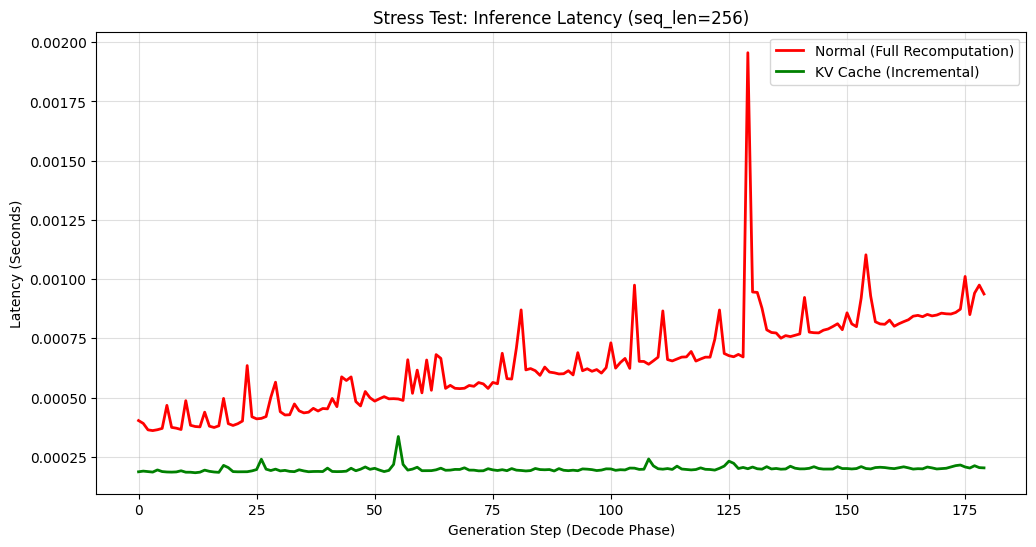

In [20]:
import time
import torch
import matplotlib.pyplot as plt

long_seq_len = 256      # 上下文窗口放大到 256
long_d_model = 128      # 维度翻倍，增加矩阵乘法的计算密度
long_n_heads = 4
long_hidden_dim = 256

torch.manual_seed(42)

print(f"🔥 正在初始化长上下文模型 (seq_len={long_seq_len}, d_model={long_d_model})...")

# 我们需要重新定义一下基础组件的维度来匹配新的超参数
class LongMiniLLM(nn.Module):
    def __init__(self):
        super().__init__()
        self.embed = Embeddings(vocab_size, long_d_model, long_seq_len)
        self.block = TransformerBlock(long_d_model, long_n_heads, long_hidden_dim)
        self.final_norm = RMSNorm(long_d_model)
        self.lm_head = nn.Linear(long_d_model, vocab_size, bias=False)
        self.lm_head.weight = self.embed.token_emb.weight

    def forward(self, x):
        x = self.embed(x)
        x = self.block(x)
        x = self.final_norm(x)
        return self.lm_head(x)

long_model = LongMiniLLM()


# 构造一个长度为 64 的初始输入 (远小于 long_seq_len，给后续生成留出空间)
start_length = 64
long_start_tokens = torch.randint(0, vocab_size, (1, start_length))


# 我们设定生成 180 个新词，这会使总长度逼近 240，充分展现 O(N^2) 的爆炸
max_generate_steps = 180 

def run_stress_test(model, start_tokens, max_gen):
    # --- Warmup ---
    dummy = torch.zeros((1, 1), dtype=torch.long)
    for _ in range(5):
        _ = model(dummy)
        
    # --- 方案 A: 全量重算 (Normal) ---
    times_normal = []
    curr_ids = start_tokens.clone()
    print("⏳ 正在运行 Normal 模式...")
    for i in range(max_gen):
        start = time.perf_counter()
        _ = model(curr_ids)
        times_normal.append(time.perf_counter() - start)
        next_id = torch.randint(0, vocab_size, (1, 1))
        curr_ids = torch.cat([curr_ids, next_id], dim=1)

    # --- 方案 B: KV Cache (增量) ---
    times_kv = []
    kv_model = KVCacheModel(model) 
    print("⏳ 正在运行 KV Cache 模式...")
    
    # Prefill 阶段
    for i in range(start_tokens.size(1) - 1):
        _ = kv_model.incremental_forward(start_tokens[:, i:i+1], step=i)
        
    curr_token = start_tokens[:, -1:]
    
    # Decode 阶段
    for i in range(max_gen):
        start = time.perf_counter()
        _ = kv_model.incremental_forward(curr_token, step=start_tokens.size(1) - 1 + i)
        times_kv.append(time.perf_counter() - start)
        next_id = torch.randint(0, vocab_size, (1, 1))
        curr_token = next_id 

    return times_normal, times_kv

t_normal_long, t_kv_long = run_stress_test(long_model, long_start_tokens, max_generate_steps)

plt.figure(figsize=(12, 6))

plt.plot(t_normal_long, label="Normal (Full Recomputation)", color="red", linewidth=2)
plt.plot(t_kv_long, label="KV Cache (Incremental)", color="green", linewidth=2)

plt.title(f"Stress Test: Inference Latency (seq_len={long_seq_len})")
plt.xlabel("Generation Step (Decode Phase)")
plt.ylabel("Latency (Seconds)")
plt.legend()
plt.grid(True, alpha=0.4)

# 动态计算加速比
speedup_at_end = t_normal_long[-1] / t_kv_long[-1]


plt.show()

In [21]:
import torch
import torch.nn.functional as F

# 格式化 PyTorch 的打印输出，方便我们清晰地查看完整的矩阵
torch.set_printoptions(linewidth=120, sci_mode=False, precision=3)

print("="*60)
print("🔍 1. 模型全息结构展示 (Model Architecture)")
print("="*60)
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"\n📊 总参数量: {total_params / 1000:.1f} K")

print("\n" + "="*60)
print("🔬 2. 模型生成过程")
print("="*60)

sample_text = "I"
curr_ids = torch.tensor([[dataset.char_to_id[c] for c in sample_text]], dtype=torch.long)

print(f"📥 初始输入文本: '{sample_text}'")
print(f"🔢 初始 ID 张量: {curr_ids.tolist()}")

# 我们让模型连续自回归生成 15 个字符
num_generate = 15

model.eval()
with torch.no_grad():
    for step in range(num_generate):
        print(f"\n\n" + "▼"*60)
        print(f"🚀 第 {step+1} 步前向传播 (当前上下文: '{sample_text}')")
        print("▼" * 60)
        
        # 手动拆解前向传播
        x_emb = model.embed(curr_ids)
        x_block = model.block(x_emb)
        x_norm = model.final_norm(x_block)
        logits = model.lm_head(x_norm)
        
        # 仅在第 1 步展示完整的浮点数矩阵
        if step == 0:
            print(f"\n[1] ⬇️ 经过 Embedding 层 (Token嵌入 + Pos位置编码) | 形状: {x_emb.shape}")
            print("【完整矩阵数值】(由于输入2个字符，这里是 2行 x 64列):")
            print(x_emb[0]) 
            
            print(f"\n[2] ⬇️ 经过 Transformer Block (Attention 混合 + FFN 推理) | 形状: {x_block.shape}")
            print("【完整矩阵数值】(注意数值是如何被 Attention 和非线性激活改变的):")
            print(x_block[0])
            
            print(f"\n[3] ⬇️ 经过 Final RMSNorm (数值防爆处理) | 形状: {x_norm.shape}")
            print("【完整矩阵数值】(观察每一行的均方根是否被拉回了标准的尺度):")
            print(x_norm[0])
        
        # --- 概率解码逻辑 ---
        # 取出当前序列最后一个字对应的 Logits 向量
        last_step_logits = logits[0, -1, :] 
        probs = F.softmax(last_step_logits, dim=-1)
        
        # 找排名前三的候选
        top_k = 3
        top_probs, top_indices = torch.topk(probs, top_k)
        
        print(f"\n🧠 模型对下一个位置的 Top-{top_k} 预测分布:")
        for i in range(top_k):
            char_id = top_indices[i].item()
            
            # 如果输出的 ID 超出了字典长度，显示为未知词 <UNK>
            if char_id < len(dataset.chars):
                char = dataset.chars[char_id]
            else:
                char = f"<UNK_ID:{char_id}>"
                
            prob = top_probs[i].item() * 100
            print(f"   ► 选项 {i+1}: 字符 '{char}' (ID: {char_id:04d})，自信度: {prob:5.2f}%")
            
        # 贪心策略：直接取概率最大的词
        best_id = top_indices[0].unsqueeze(0).unsqueeze(0) 
        best_id_val = best_id.item()
        
        # 同样的保护逻辑
        if best_id_val < len(dataset.chars):
            best_char = dataset.chars[best_id_val]
        else:
            best_char = "?" # 如果模型真抽风选了越界词，用问号代替
            
        # 拼接
        curr_ids = torch.cat([curr_ids, best_id], dim=1)
        sample_text += best_char
        print(f"✨ 模型本轮拍板决定输出: '{best_char}'")

print("\n\n" + "="*60)
print(f"🎉 最终生成的完整推断结果: '{sample_text}'")
print("="*60)

🔍 1. 模型全息结构展示 (Model Architecture)
MiniLLM(
  (embed): Embeddings(
    (token_emb): Embedding(1024, 64)
    (pos_emb): Embedding(16, 64)
  )
  (block): TransformerBlock(
    (norm1): RMSNorm()
    (attn): MultiHeadAttention()
    (norm2): RMSNorm()
    (ffn): SwiGLU(
      (w1): Linear(in_features=64, out_features=172, bias=False)
      (w2): Linear(in_features=64, out_features=172, bias=False)
      (w3): Linear(in_features=172, out_features=64, bias=False)
    )
  )
  (final_norm): RMSNorm()
  (lm_head): Linear(in_features=64, out_features=1024, bias=False)
)

📊 总参数量: 99.8 K

🔬 2. 模型生成过程
📥 初始输入文本: 'I'
🔢 初始 ID 张量: [[8]]


▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼
🚀 第 1 步前向传播 (当前上下文: 'I')
▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼▼

[1] ⬇️ 经过 Embedding 层 (Token嵌入 + Pos位置编码) | 形状: torch.Size([1, 1, 64])
【完整矩阵数值】(由于输入2个字符，这里是 2行 x 64列):
tensor([[ 0.007,  2.166, -1.799, -1.259,  0.951, -1.300, -2.034, -0.906,  1.644, -0.740, -0.890, -1.379, -1.702, -1.0